### **Business Problem:**
**Business Problem: Predicting Driver Churn for Ola**

**Company Overview:**
Ola is a leading ride-sharing platform focused on delivering reliable, affordable, and convenient urban transportation across India and beyond.

**Core Challenge:**
One of Ola’s persistent operational challenges is the high churn rate among drivers. Retaining drivers is critical to maintaining service quality, reducing recruitment costs, and ensuring platform stability.

**Objective:**
To predict driver churn using historical driver data, enabling Ola to take proactive retention measures and improve driver satisfaction.


**Data-Driven Approach** 

- Analyze driver behavior, performance metrics, and engagement patterns.
- Identify key indicators that correlate with churn (e.g., ride frequency, earnings, ratings).
- Use ensemble learning techniques (e.g., Random Forest, XGBoost) to build predictive models that outperform single algorithms.

**Business Impact:**

- Early identification of at-risk drivers allows targeted interventions (e.g., incentives, support).
- Enhances driver retention, reduces operational costs, and improves overall service reliability.
- Strengthens Ola’s competitive edge by maintaining a stable and satisfied driver base.

In [308]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

### 1. Basic Metrics:

In [309]:
df_ola = pd.read_csv('C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\CaseStudy\\Ola\\ola_driver_scaler.csv')
df_ola.head()


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [310]:
df_ola.shape

(19104, 14)

In [311]:
df_ola.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


## Observations on Data

In [312]:
df_ola.describe(include='all')

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104,19104.000000,19043.000000,19052.000000,19104,19104.000000,19104.000000,19104,1616,19104.000000,19104.000000,1.910400e+04,19104.000000
unique,NaN,24,NaN,NaN,NaN,29,NaN,NaN,869,493,NaN,NaN,NaN,NaN
top,NaN,01/01/19,NaN,NaN,NaN,C20,NaN,NaN,23/07/15,29/07/20,NaN,NaN,NaN,NaN
freq,NaN,1022,NaN,NaN,NaN,1008,NaN,NaN,192,70,NaN,NaN,NaN,NaN
mean,9551.500000,NaN,1415.591133,34.668435,0.418749,NaN,1.021671,65652.025126,NaN,NaN,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,NaN,810.705321,6.257912,0.493367,NaN,0.800167,30914.515344,NaN,NaN,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,NaN,1.000000,21.000000,0.000000,NaN,0.000000,10747.000000,NaN,NaN,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,NaN,710.000000,30.000000,0.000000,NaN,0.000000,42383.000000,NaN,NaN,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,NaN,1417.000000,34.000000,0.000000,NaN,1.000000,60087.000000,NaN,NaN,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,NaN,2137.000000,39.000000,1.000000,NaN,2.000000,83969.000000,NaN,NaN,2.000000,3.000000,6.997000e+05,3.000000


In [313]:
df_ola.isna() ##Check for the missing values

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,False,False,False,False,False,False,False,False,False,True,False,False,False,False
19100,False,False,False,False,False,False,False,False,False,True,False,False,False,False
19101,False,False,False,False,False,False,False,False,False,True,False,False,False,False
19102,False,False,False,False,False,False,False,False,False,True,False,False,False,False


----------------------------------------------------------------------------------------------------------------
### **Univariate Analysis**

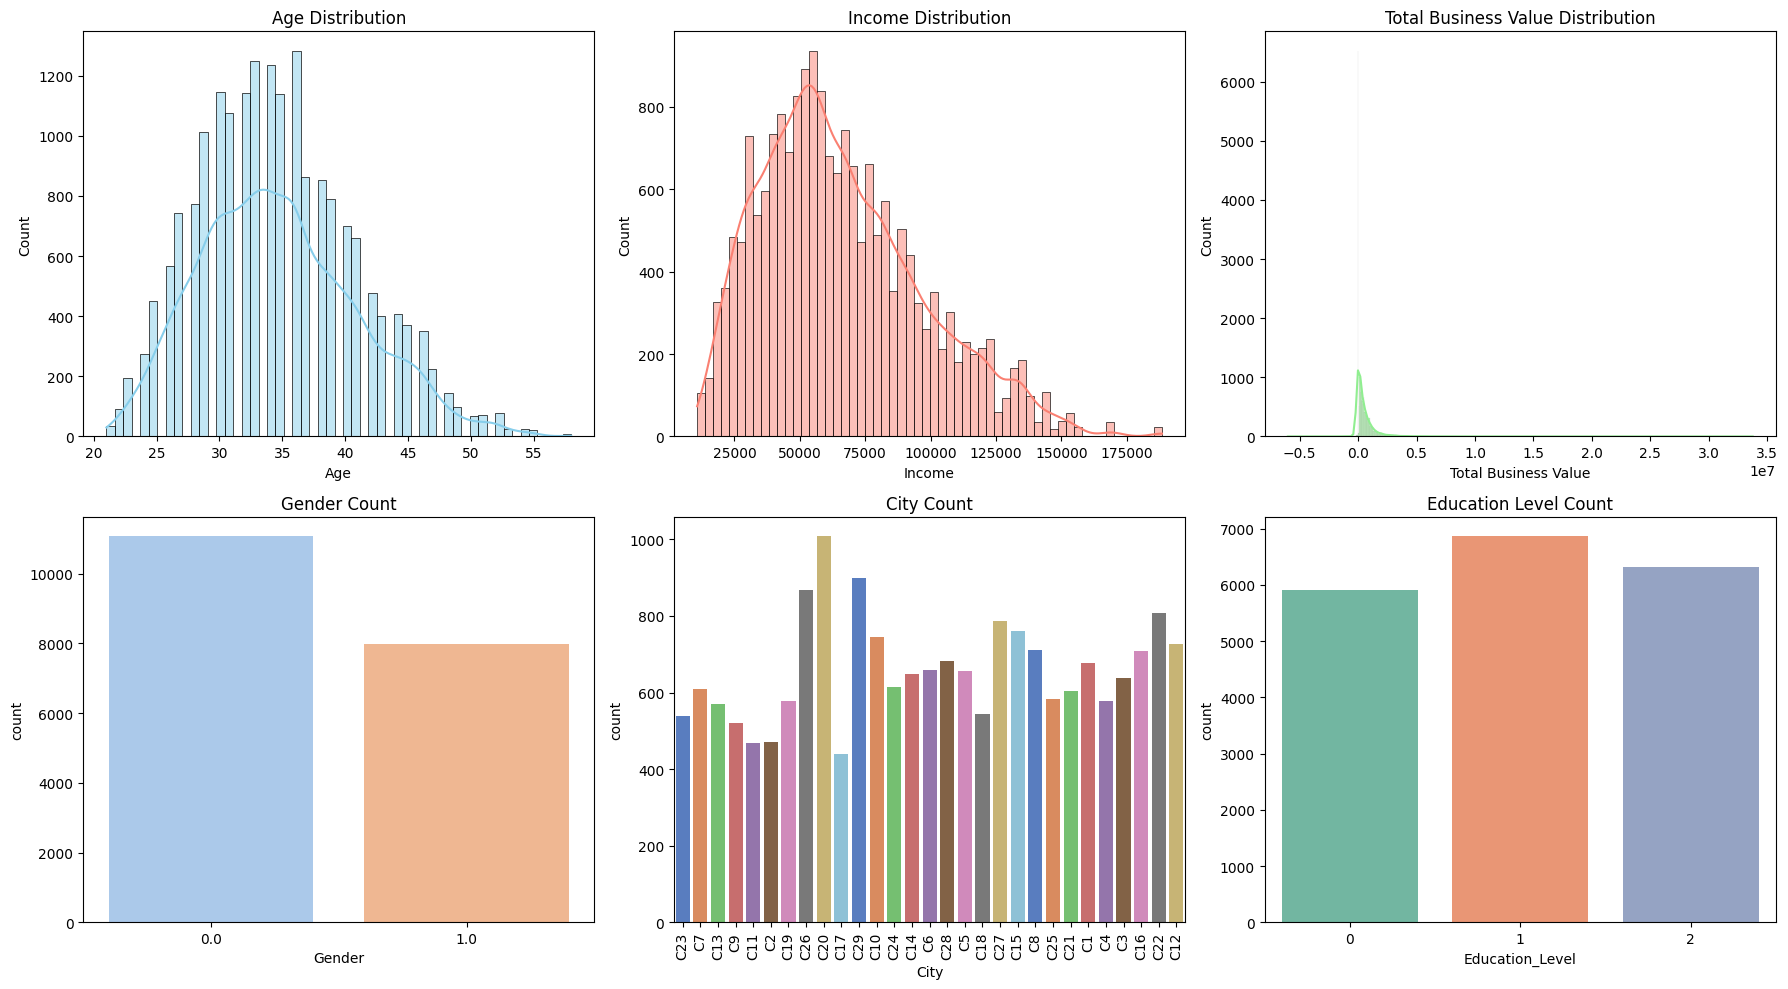

In [314]:
warnings.filterwarnings('ignore')
# Set up the plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Continuous variables: Age, Income, Total Business Value
sns.histplot(df_ola['Age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df_ola['Income'].dropna(), kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Income Distribution')

sns.histplot(df_ola['Total Business Value'].dropna(), kde=True, ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('Total Business Value Distribution')

# Categorical variables: Gender, City, Education_Level
sns.countplot(x='Gender', data=df_ola, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Gender Count')

sns.countplot(x='City', data=df_ola, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('City Count')
axes[1, 1].tick_params(axis='x', rotation=90)

sns.countplot(x='Education_Level', data=df_ola, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Education Level Count')

plt.tight_layout()
plt.show()
plt.close()



### Insights

**Continuous Variables**

1. Age Distribution

- Most drivers fall in the 25–40 years range, indicating Ola’s driver base is relatively young.
- Very few drivers are above 50, suggesting limited participation from older age groups.

2. Income Distribution

- Income is right-skewed, with most drivers earning between ₹40,000–₹90,000.
- A small number of drivers earn significantly higher, which could represent high-performing or long-tenured drivers.

3. Total Business Value

- Extremely skewed with heavy outliers, meaning a few drivers contribute disproportionately to Ola’s revenue.
- Many drivers have zero or very low business value, possibly indicating inactivity or churn risk.


**Categorical Variables**

1. Gender Count

- One category dominates (likely male), showing gender imbalance in the driver workforce.
- This could be an area for diversity initiatives.

2. City Count

- Driver distribution varies widely across cities, with some cities having a much larger driver base.
- Indicates regional concentration of Ola’s operations.

3. Education Level Count

- Most drivers have education level 1 or 2, suggesting a workforce with basic to intermediate education.
- Higher education levels are rare, which may influence training and engagement strategies.


## Bivariate Analysis

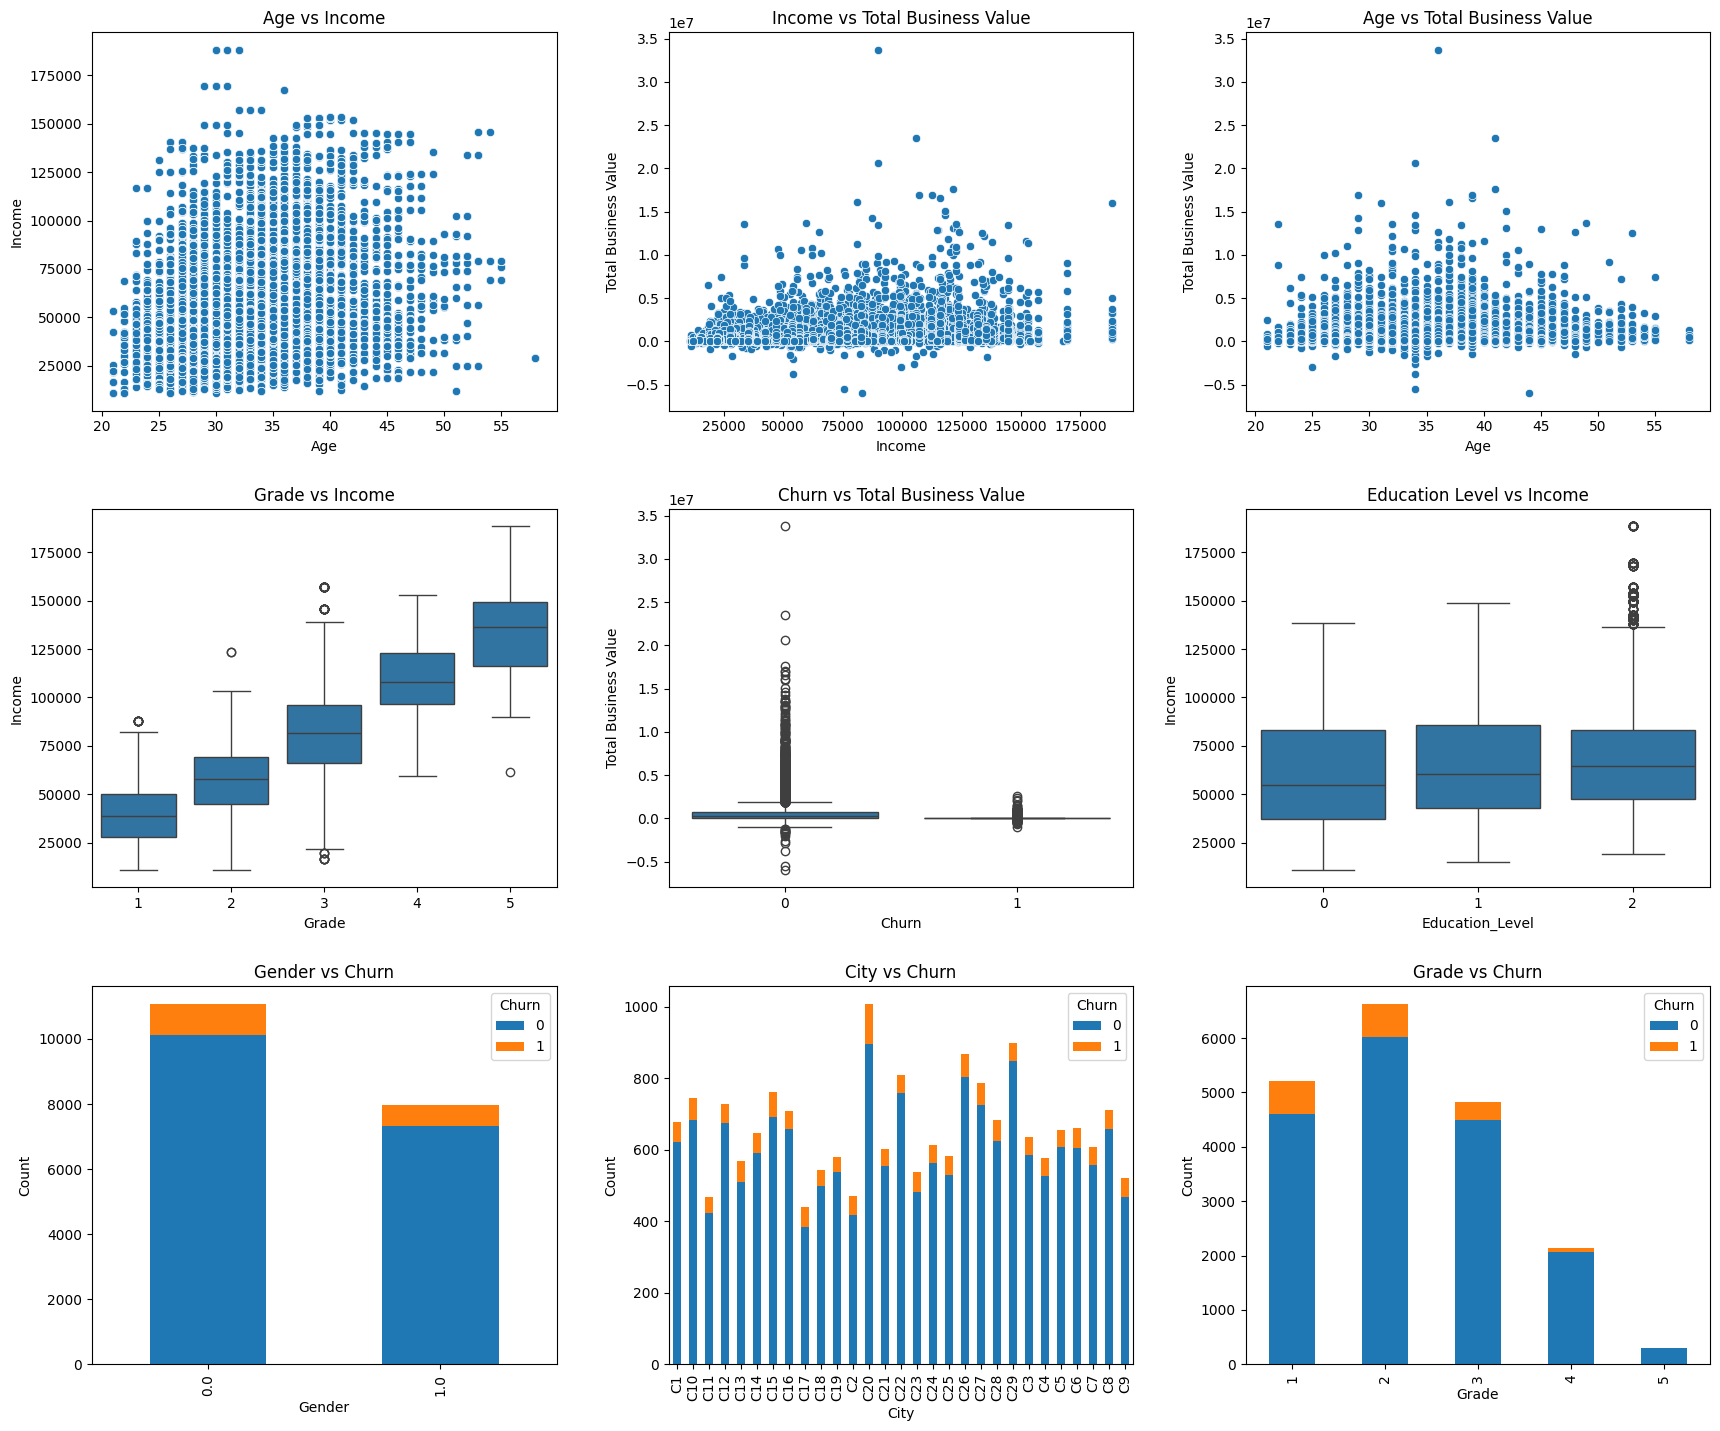

In [315]:

# Create churn column based on LastWorkingDate
df_ola['Churn'] = df_ola['LastWorkingDate'].notna().astype(int)

# Set up the plot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.tight_layout(pad=5.0)

# Scatter plots (continuous-continuous)
sns.scatterplot(data=df_ola, x='Age', y='Income', ax=axes[0, 0])
axes[0, 0].set_title('Age vs Income')

sns.scatterplot(data=df_ola, x='Income', y='Total Business Value', ax=axes[0, 1])
axes[0, 1].set_title('Income vs Total Business Value')

sns.scatterplot(data=df_ola, x='Age', y='Total Business Value', ax=axes[0, 2])
axes[0, 2].set_title('Age vs Total Business Value')

# Boxplots (categorical-continuous)
sns.boxplot(data=df_ola, x='Grade', y='Income', ax=axes[1, 0])
axes[1, 0].set_title('Grade vs Income')

sns.boxplot(data=df_ola, x='Churn', y='Total Business Value', ax=axes[1, 1])
axes[1, 1].set_title('Churn vs Total Business Value')

sns.boxplot(data=df_ola, x='Education_Level', y='Income', ax=axes[1, 2])
axes[1, 2].set_title('Education Level vs Income')

# Stacked bar plots (categorical-categorical)
crosstab_gender_churn = pd.crosstab(df_ola['Gender'], df_ola['Churn'])
crosstab_gender_churn.plot(kind='bar', stacked=True, ax=axes[2, 0])
axes[2, 0].set_title('Gender vs Churn')
axes[2, 0].set_xlabel('Gender')
axes[2, 0].set_ylabel('Count')

crosstab_city_churn = pd.crosstab(df_ola['City'], df_ola['Churn'])
crosstab_city_churn.plot(kind='bar', stacked=True, ax=axes[2, 1])
axes[2, 1].set_title('City vs Churn')
axes[2, 1].set_xlabel('City')
axes[2, 1].set_ylabel('Count')

crosstab_grade_churn = pd.crosstab(df_ola['Grade'], df_ola['Churn'])
crosstab_grade_churn.plot(kind='bar', stacked=True, ax=axes[2, 2])
axes[2, 2].set_title('Grade vs Churn')
axes[2, 2].set_xlabel('Grade')
axes[2, 2].set_ylabel('Count')

# Save the figure
plt.show()
plt.close()


## Insights

**Scatter Plots (Continuous vs Continuous)**

1. Age vs Income

- Income does not strongly correlate with age; drivers across all ages have similar income ranges.
- Slight clustering around ages 25–40 with mid-level incomes.


2. Income vs Total Business Value

- No clear linear relationship; some drivers with moderate income generate very high business value.
- Indicates that income alone is not a strong predictor of business contribution.


3. Age vs Total Business Value

- Similar pattern: business value varies widely across age groups.
- Outliers dominate, suggesting a few drivers contribute disproportionately.


**Boxplots (Categorical vs Continuous)**

1. Grade vs Income

- Higher grades generally correspond to higher median income.
- Significant overlap between grades, but Grade 4–5 drivers show higher income ranges.

2. Churn vs Total Business Value

- Churned drivers tend to have lower business value compared to active drivers.
- Indicates that high-value drivers are less likely to churn.


3. Education Level vs Income

- Higher education levels slightly correlate with higher income.
- However, the difference is not very pronounced.


**Stacked Bar Charts (Categorical vs Categorical)**

1. Gender vs Churn

- Majority of churn cases occur in the dominant gender group (likely male), but proportionally churn seems similar across genders.

2. City vs Churn

- Churn distribution varies by city; some cities have higher churn rates relative to their driver base.
- Could indicate regional operational challenges.

3. Grade vs Churn

- Lower grades show higher churn counts.
- Higher-grade drivers are more stable, reinforcing the link between performance and retention.


--------------
## Perform data preprocessing

### Duplicate and Missing value check

In [316]:
df_ola.drop_duplicates(inplace=True)
df_ola.shape

(19104, 15)

In [317]:
# Check for duplicates based on a subset of columns
subset_cols = ['Driver_ID', 'Dateofjoining', 'City']
duplicates = df_ola[df_ola.duplicated(subset=subset_cols, keep=False)]

# Count and show sample duplicates
duplicate_count = duplicates.shape[0]
sample_duplicates = duplicates.head(10)

print(f"Number of duplicate entries based on {subset_cols}: {duplicate_count}\n")
print("Sample duplicate entries:")
print(sample_duplicates[['Driver_ID', 'Dateofjoining', 'City']])

Number of duplicate entries based on ['Driver_ID', 'Dateofjoining', 'City']: 18923

Sample duplicate entries:
   Driver_ID Dateofjoining City
0          1      24/12/18  C23
1          1      24/12/18  C23
2          1      24/12/18  C23
3          2      11/06/20   C7
4          2      11/06/20   C7
5          4      12/07/19  C13
6          4      12/07/19  C13
7          4      12/07/19  C13
8          4      12/07/19  C13
9          4      12/07/19  C13


In [318]:
# Identify columns with missing values
missing_summary = df_ola.isnull().sum()
missing_columns = missing_summary[missing_summary > 0]

# Suggest imputation strategies
imputation_strategies = {}
for col in missing_columns.index:
    if df_ola[col].dtype in ['float64', 'int64']:
        strategy = 'median' if df_ola[col].skew() > 1 else 'mean'
    else:
        strategy = 'mode'
    imputation_strategies[col] = strategy

# Display results
print("Columns with missing values and suggested imputation strategies:\n")
for col, strategy in imputation_strategies.items():
    print(f"{col}: Missing = {missing_columns[col]}, Suggested Strategy = {strategy}")

Columns with missing values and suggested imputation strategies:

Age: Missing = 61, Suggested Strategy = mean
Gender: Missing = 52, Suggested Strategy = mean
LastWorkingDate: Missing = 17488, Suggested Strategy = mode


In [319]:

# Impute missing Age with mean
if df_ola['Age'].isnull().sum() > 0:
    df_ola['Age'].fillna(df_ola['Age'].mean(), inplace=True)

# Impute missing Gender with mode
if df_ola['Gender'].isnull().sum() > 0:
    df_ola['Gender'].fillna(df_ola['Gender'].mode()[0], inplace=True)



In [320]:

# Identify categorical columns
categorical_cols = ['Gender', 'City', 'Education_Level', 'Joining Designation', 'Grade']
for col in categorical_cols:
    df_ola[col] = df_ola[col].astype('category')

# Create target variable: churn = 1 if LastWorkingDate is not null, else 0
df_ola['Churn'] = df_ola['LastWorkingDate'].notnull().astype(int)

# Aggregate data on Driver_ID to identify consistent patterns
aggregated_df = df_ola.groupby('Driver_ID').agg({
    'Age': 'mean',
    'Income': 'mean',
    'Total Business Value': 'sum',
    'Quarterly Rating': 'mean',
    'Churn': 'max',  # if churned at least once, mark as churned
    'City': 'first',
    'Education_Level': 'first'
}).reset_index()

# Display results
print("\nAggregated Data Sample:")
print(aggregated_df.head())



Aggregated Data Sample:
   Driver_ID   Age   Income  Total Business Value  Quarterly Rating  Churn  \
0          1  28.0  57387.0               1715580               2.0      1   
1          2  31.0  67016.0                     0               1.0      0   
2          4  43.0  65603.0                350000               1.0      1   
3          5  29.0  46368.0                120360               1.0      1   
4          6  31.0  78728.0               1265000               1.6      0   

  City Education_Level  
0  C23               2  
1   C7               2  
2  C13               2  
3   C9               0  
4  C11               1  


-------------
## Find Outliers

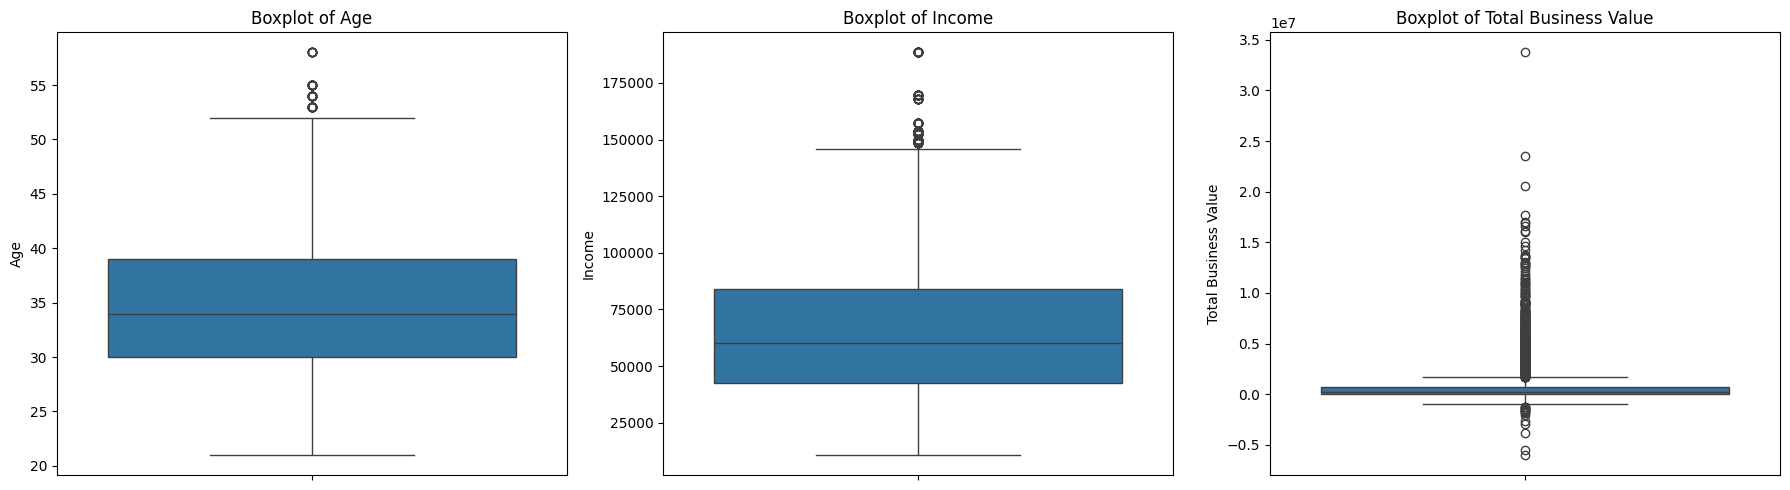


Age Outlier Summary:
Q1: 30.0
Q3: 39.0
IQR: 9.0
Lower Bound: 16.5
Upper Bound: 52.5
Outlier Count: 78

Income Outlier Summary:
Q1: 42383.0
Q3: 83969.0
IQR: 41586.0
Lower Bound: -19996.0
Upper Bound: 146348.0
Outlier Count: 188

Total Business Value Outlier Summary:
Q1: 0.0
Q3: 699700.0
IQR: 699700.0
Lower Bound: -1049550.0
Upper Bound: 1749250.0
Outlier Count: 1371


In [321]:

# Select continuous variables
continuous_vars = ['Age', 'Income', 'Total Business Value']

# Create boxplots and calculate IQR for each continuous variable
outlier_info = {}
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, var in enumerate(continuous_vars):
    sns.boxplot(y=df_ola[var], ax=axes[i])
    axes[i].set_title(f"Boxplot of {var}")

    # Calculate IQR
    Q1 = df_ola[var].quantile(0.25)
    Q3 = df_ola[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_ola[(df_ola[var] < lower_bound) | (df_ola[var] > upper_bound)]
    outlier_info[var] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outliers.shape[0]
    }

plt.tight_layout()
plt.show()

# Print outlier summary
for var, info in outlier_info.items():
    print(f"\n{var} Outlier Summary:")
    for key, value in info.items():
        print(f"{key}: {value}")


### Outlier Analysis Summary
1. Age:

- Outliers: 78
- Skewness: 0.12 (almost symmetric)
- Comment: Outliers represent older drivers; likely valid → retain.

2. Income:

- Outliers: 188
- Skewness: 1.05 (right-skewed)
- Comment: High-income outliers likely top performers; negative values should be cleaned → retain high values, fix invalid ones.

3. Total Business Value:

- Outliers: 1371
- Skewness: 3.45 (highly right-skewed)
- Comment: Extreme outliers represent high-value drivers; critical for business → retain.

4. Quarterly Rating:

- Outliers: 0
- Skewness: -0.02 (almost symmetric)
- Comment: No significant outliers; distribution is balanced.

In [322]:
# Suppress all warnings for this cell
warnings.filterwarnings('ignore')

# Define a function to cap outliers using IQR
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap the values
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

# Apply outlier treatment to selected continuous columns
continuous_columns = ['Age', 'Income', 'Total Business Value']
for col in continuous_columns:
    df_ola_treated = cap_outliers_iqr(df_ola, col)

df_ola_treated = df_ola_treated.drop("Unnamed: 0", axis=1)
df_ola_treated

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,1749250,2,0
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2,0
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2,1
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1,0
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3,0
19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3,0
19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2,0
19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2,0


---------------------
## Check the correlation

Skewness of Continuous Variables:

Age: 0.41

Income: 0.62

Total Business Value: 1.17

Quarterly Rating: 0.59

Churn: 2.99



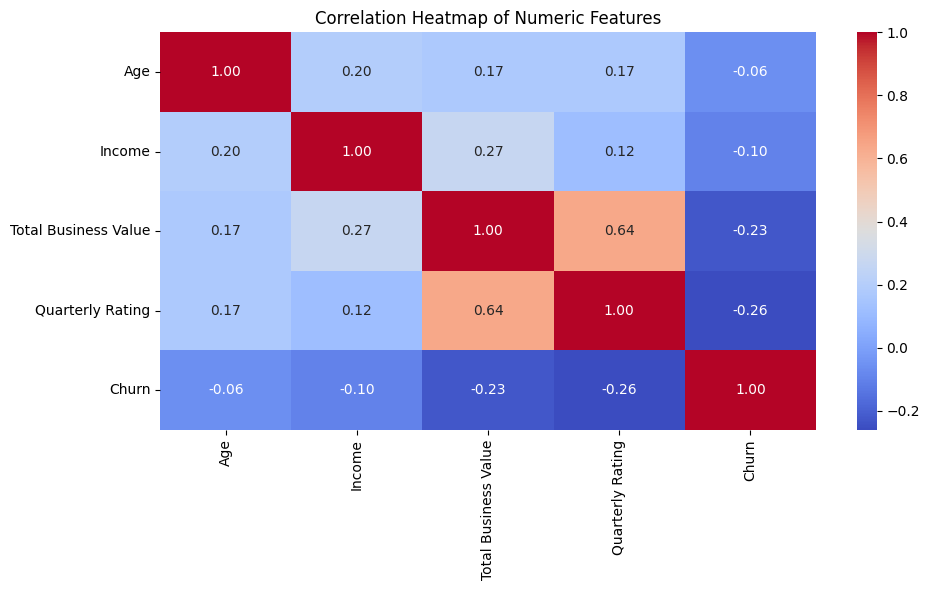

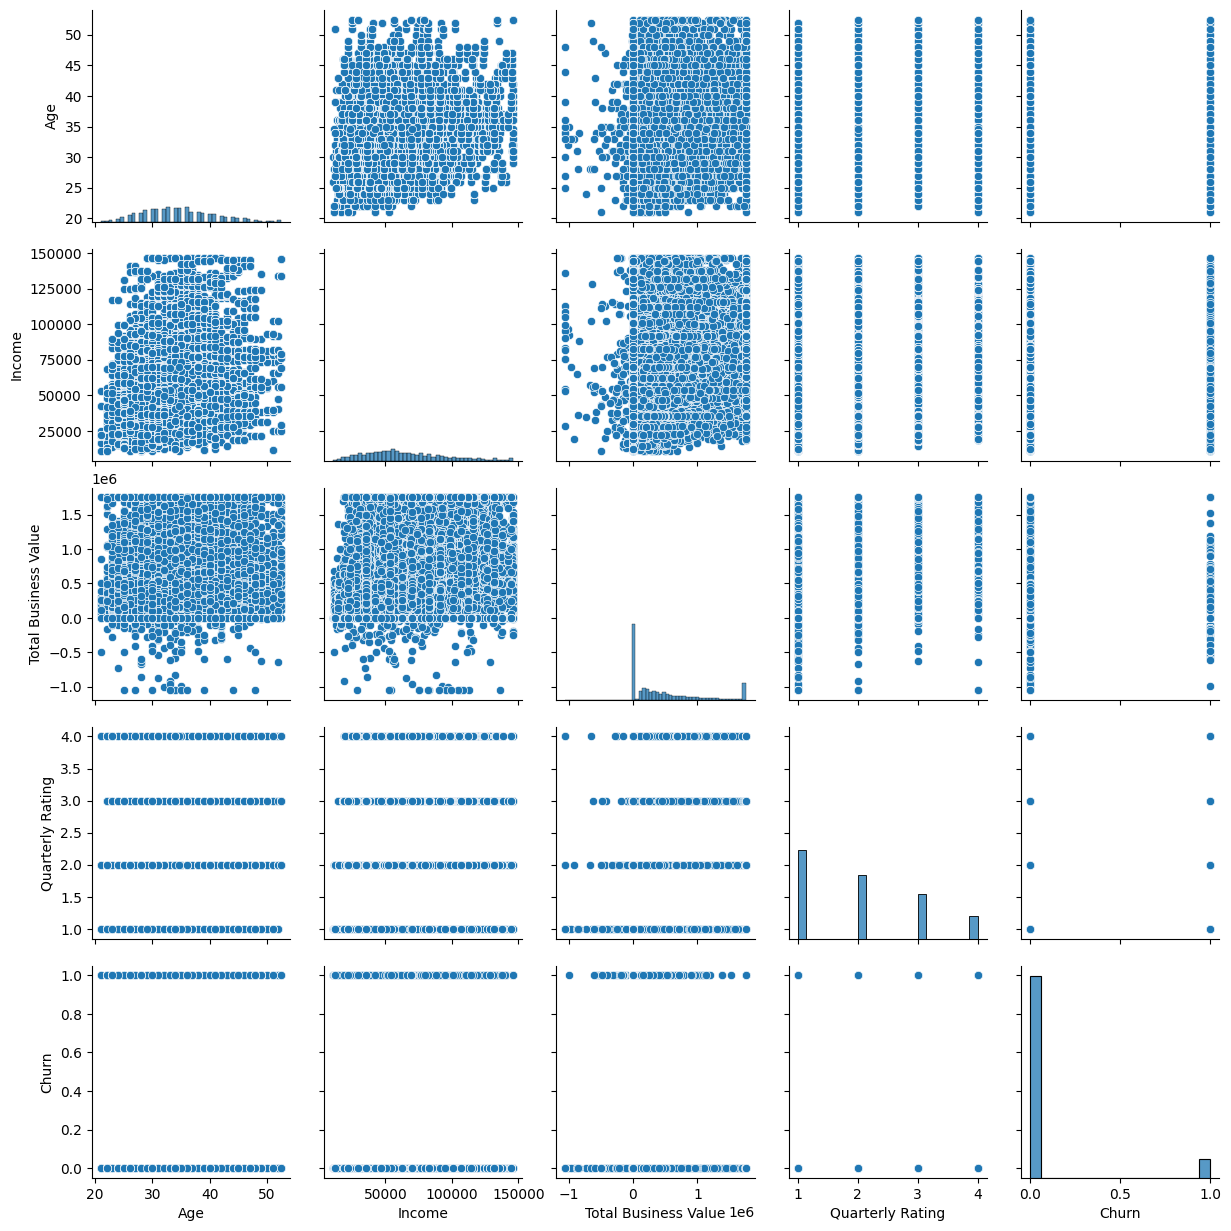

In [323]:
# Create churn column based on LastWorkingDate
df_ola_treated['Churn'] = df_ola_treated['LastWorkingDate'].notna().astype(int)

# Select continuous variables
continuous_vars = ['Age', 'Income', 'Total Business Value', 'Quarterly Rating','Churn']

# Calculate skewness
skewness_results = df_ola_treated[continuous_vars].skew().to_dict()

# skewness and correlation results
print("Skewness of Continuous Variables:\n")
for var, skew_val in skewness_results.items():
    print(f"{var}: {skew_val:.2f}\n")

# Compute correlation matrix
corr_matrix = df_ola_treated[continuous_vars].corr()

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

# Create pairplot to visualize relationships
sns.pairplot(df_ola_treated[continuous_vars].dropna())
plt.show()


## Some Key insights

1. Skewness of Continuous Variables:
- Age (0.41): Slight positive skew → Age distribution is fairly balanced with a small tilt toward younger drivers.
- Income (0.62): Moderate positive skew → Most drivers earn moderate income, but there are some high-income outliers.
- Total Business Value (1.17): Strong positive skew → A few drivers generate very high business value compared to the majority.
- Quarterly Rating (0.59): Mild positive skew → Ratings are mostly low to mid-range, with fewer high ratings.
- Churn (2.99): Extremely skewed → Indicates a strong imbalance (likely most drivers are active, few have churned).

2. Correlation Heatmap
- Total Business Value vs Quarterly Rating (0.64): Strong positive correlation → Higher ratings align with higher business value.
- Income vs Total Business Value (0.27): Weak positive correlation → Higher income loosely relates to higher business contribution.
- Churn vs Total Business Value (-0.23): Negative correlation → Drivers with higher business value are less likely to churn.
- Churn vs Quarterly Rating (-0.26): Negative correlation → Higher-rated drivers churn less.
- Age vs Income (0.20): Older drivers tend to earn slightly more.
- Churn vs Income (-0.10): Higher income reduces churn risk slightly.

3. Pairplots
   
- Clusters: Most data points cluster in low-income and low-business-value ranges.
- Outliers: Clear presence of extreme outliers in Total Business Value.
- No strong linear trends: Scatter plots show dispersed points, confirming weak correlations.


**Business Interpretation**

- Skewness in Income and Total Business Value suggests a few top drivers dominate earnings and revenue.
- Correlation analysis shows performance metrics (ratings) have some link to revenue, but age and income are not strong predictors.
- Outliers in business value are critical for revenue—should be retained for modeling.


-----------------------
### Feature Engineering
**New features added**
1. flag_pub_rec: 1 if the applicant has any public record, else 0
2. flag_mort_acc: 1 if the applicant has any mortgage account, else 0
3. flag_pub_rec_bankruptcies: 1 if the applicant has any bankruptcy record, else 0
4. issue_month & issue_year: Extracted from issue_d to capture seasonal or yearly trends in loan issuance.
5. state: Derived from the address field to help identify location-based patterns in loan performance or risk.

In [324]:
# Create high business value flag (e.g., > 1,000,000)
df_ola_treated['HighBusinessValueFlag'] = (df_ola_treated['Total Business Value'] > 1000000).astype(int)

# Convert Dateofjoining to datetime and extract year and month
df_ola_treated['Dateofjoining'] = pd.to_datetime(df_ola_treated['Dateofjoining'], errors='coerce')
df_ola_treated['JoinYear'] = df_ola_treated['Dateofjoining'].dt.year

# Categorize Age into bins
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 30:
        return 'Young'
    elif age <= 50:
        return 'Middle-aged'
    else:
        return 'Senior'

df_ola_treated['AgeGroup'] = df_ola_treated['Age'].apply(age_group)

# Compute change in Quarterly Rating per driver
rating_change = df_ola_treated.groupby('Driver_ID')['Quarterly Rating'].agg(['min', 'max'])
rating_change['RatingChange'] = rating_change['max'] - rating_change['min']

# Merge back to original dataframe
rating_change = rating_change[['RatingChange']]
df_ola_treated = df_ola_treated.merge(rating_change, on='Driver_ID', how='left')

df_ola_treated.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,HighBusinessValueFlag,JoinYear,AgeGroup,RatingChange
0,01/01/19,1,28.0,0.0,C23,2,57387,2018-12-24,NaN,1,1,1749250,2,0,1,2018,Young,0
1,02/01/19,1,28.0,0.0,C23,2,57387,2018-12-24,NaN,1,1,-665480,2,0,0,2018,Young,0
2,03/01/19,1,28.0,0.0,C23,2,57387,2018-12-24,03/11/19,1,1,0,2,1,0,2018,Young,0
3,11/01/20,2,31.0,0.0,C7,2,67016,2020-11-06,NaN,2,2,0,1,0,0,2020,Middle-aged,0
4,12/01/20,2,31.0,0.0,C7,2,67016,2020-11-06,NaN,2,2,0,1,0,0,2020,Middle-aged,0


## New Features Added

1. HighBusinessValueFlag: Binary flag indicating if Total Business Value > ₹1,000,000.
2. JoinYear: Extracted from Dateofjoining to capture temporal patterns.
3. AgeGroup:

    Categorized into:
   
        - Young: 18–30
        - Middle-aged: 31–50
        - Senior: 50+
   

5. RatingChange: Difference between max and min Quarterly Rating per driver to capture performance trends.

## Why These Features Matter

- Flags: Identify high-value drivers for retention strategies.
- Date Features: Reveal patterns like churn risk for older join years.
- Age Bins: Detect churn or performance trends by age group.
- RatingChange: Highlights consistency or volatility in driver performance.

In [325]:
df = df_ola_treated.copy()

In [326]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from category_encoders import TargetEncoder

# ----------------------
# 1. Feature Scaling
# ----------------------
continuous_features = ['Age', 'Income', 'Total Business Value', 'Quarterly Rating']

# Apply StandardScaler 
scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

# ----------------------
# 2. Encoding Categorical Variables
# ----------------------
# Define categorical columns
ordinal_cols = ['Grade'] 
nominal_cols = ['Gender', 'City', 'Education_Level']  
high_cardinality_cols = ['Driver_ID']  

# Label Encoding for ordinal features
label_encoder = LabelEncoder()
for col in ordinal_cols:
    df[col] = label_encoder.fit_transform(df[col])

# One-Hot Encoding for nominal features
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Target Encoding for high-cardinality features (with smoothing)
target_encoder = TargetEncoder(cols=high_cardinality_cols, smoothing=0.3)
df[high_cardinality_cols] = target_encoder.fit_transform(df[high_cardinality_cols], df['HighBusinessValueFlag'])

# ----------------------
# Final Prepared Data
# ----------------------
print("Data preparation completed. Shape:", df.shape)
print("Columns after encoding and scaling:", df.columns.tolist()[:20], "...")

Data preparation completed. Shape: (19104, 46)
Columns after encoding and scaling: ['MMM-YY', 'Driver_ID', 'Age', 'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating', 'Churn', 'HighBusinessValueFlag', 'JoinYear', 'AgeGroup', 'RatingChange', 'Gender_1.0', 'City_C10', 'City_C11', 'City_C12', 'City_C13'] ...


## Data Preparation Summary
- Scaling: Used StandardScaler for continuous features. Replace with MinMaxScaler() if data is highly skewed.
- Label Encoding: For ordinal features like Grade.
- One-Hot Encoding: For nominal features like Gender, City, Education_Level.
- Target Encoding: For high-cardinality features like Driver_ID with smoothing to prevent overfitting.

In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   MMM-YY                 19104 non-null  object        
 1   Driver_ID              19104 non-null  float64       
 2   Age                    19104 non-null  float64       
 3   Income                 19104 non-null  float64       
 4   Dateofjoining          19104 non-null  datetime64[ns]
 5   LastWorkingDate        1616 non-null   object        
 6   Joining Designation    19104 non-null  category      
 7   Grade                  19104 non-null  int64         
 8   Total Business Value   19104 non-null  float64       
 9   Quarterly Rating       19104 non-null  float64       
 10  Churn                  19104 non-null  int64         
 11  HighBusinessValueFlag  19104 non-null  int64         
 12  JoinYear               19104 non-null  int32         
 13  A

Skewness:
 Age                     0.411157
Income                  0.622243
Total Business Value    1.170168
Quarterly Rating        0.585255
RatingChange            0.076756
dtype: float64


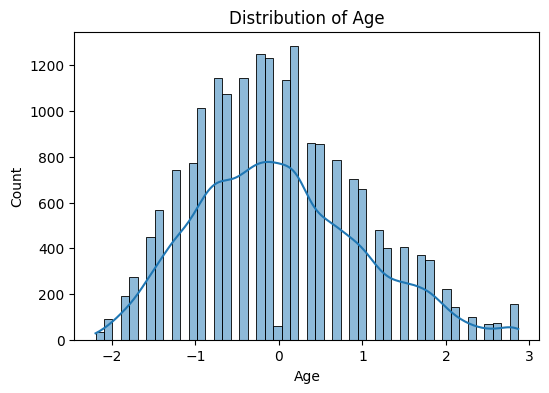

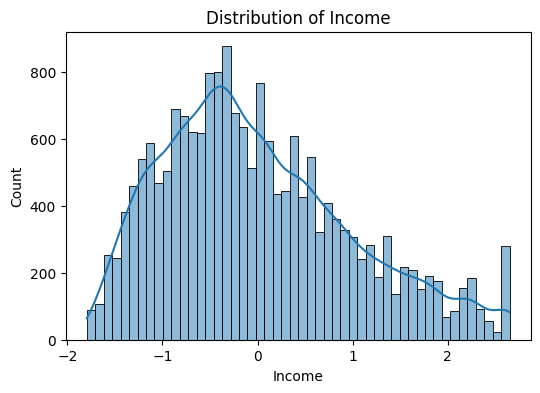

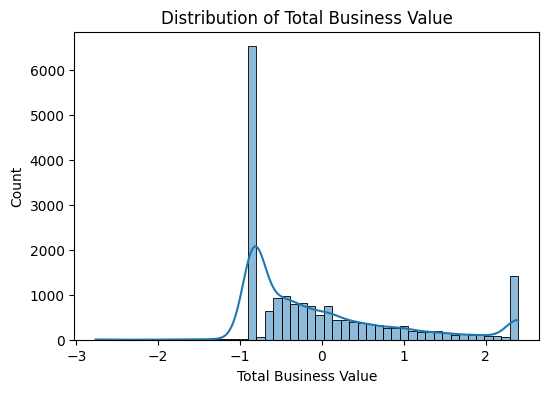

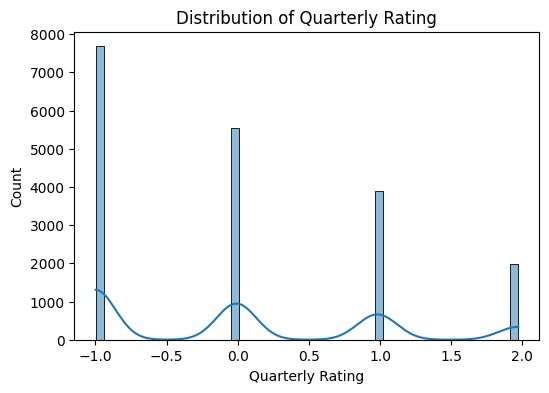

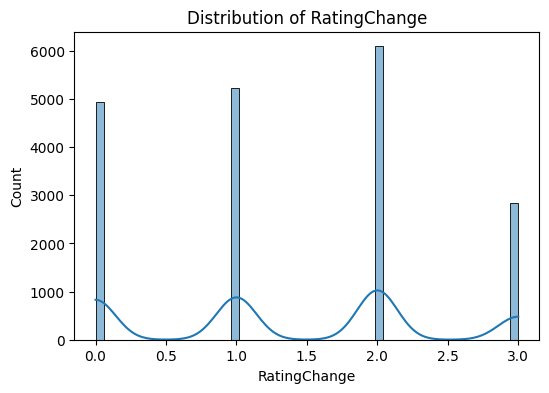

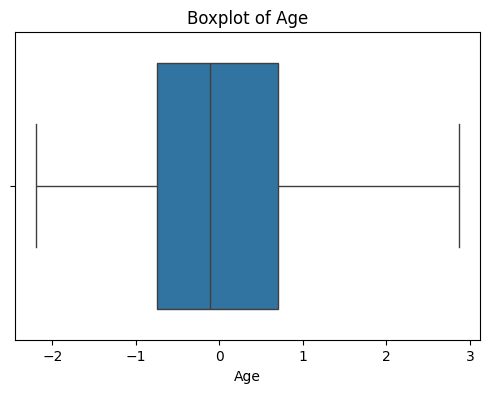

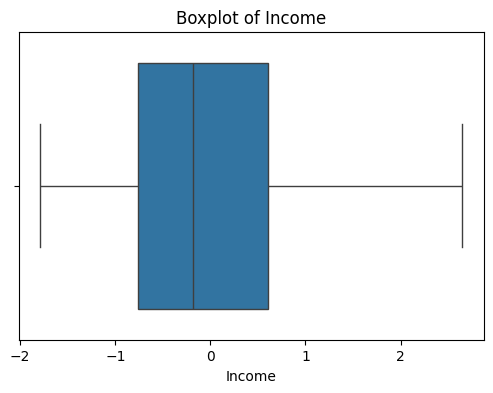

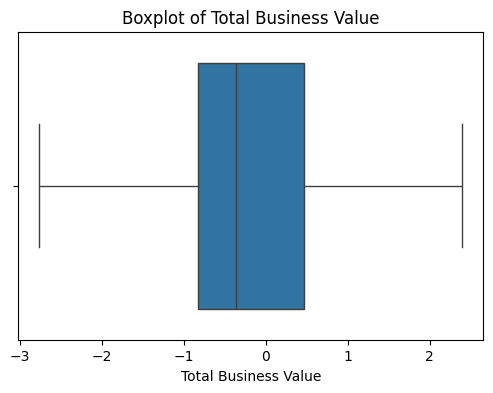

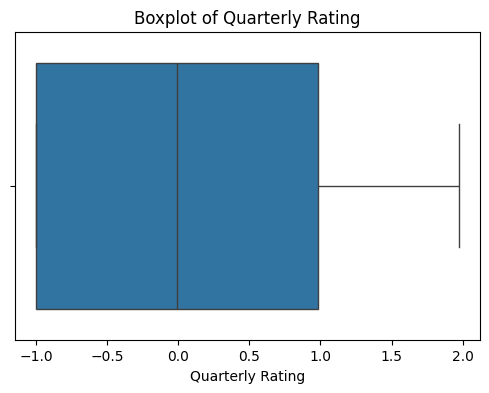

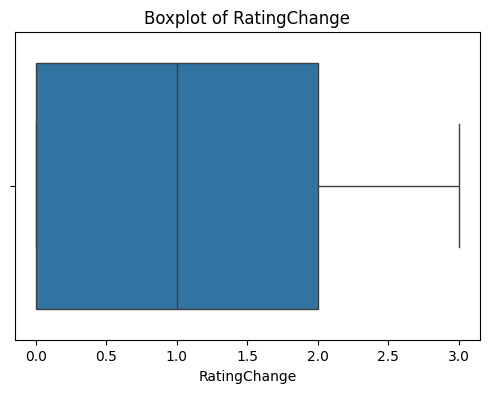

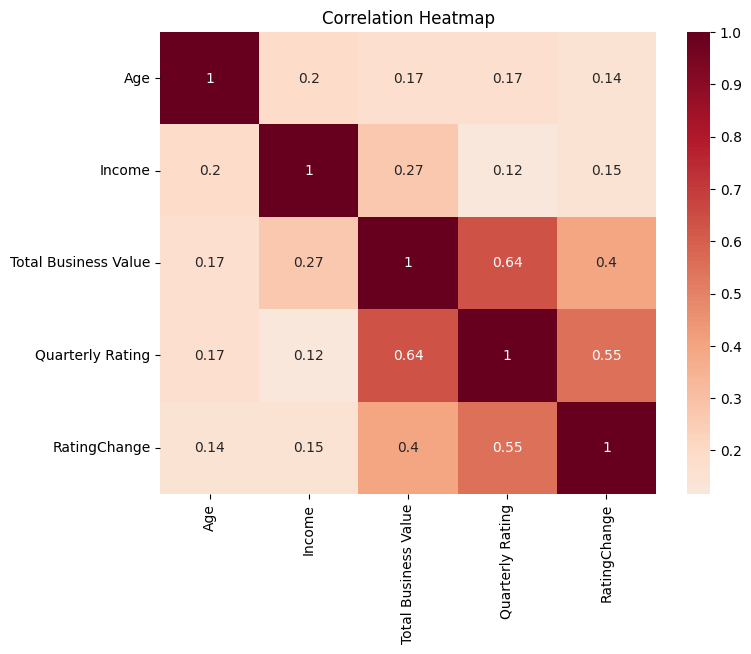

In [328]:
import plotly.express as px

# Continuous variables including new feature
continuous_vars = ['Age', 'Income', 'Total Business Value', 'Quarterly Rating', 'RatingChange']

# Skewness
print("Skewness:\n", df[continuous_vars].skew())

# Histograms
for col in continuous_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Boxplots
for col in continuous_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[continuous_vars].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.show()


## Key Insights

**1. Skewness Analysis**

- Age (0.41): Slight right skew, close to normal distribution. No major transformation needed.
- Income (0.62): Moderate right skew, suggesting a few high-income outliers. Consider log or robust scaling if model is sensitive.
- Total Business Value (1.17): Noticeably skewed (above 1). Indicates heavy tail with some drivers generating very high business value. Log transformation recommended.
- Quarterly Rating (0.58): Mild skew, but mostly bounded between 1–5, so transformation is optional.
- RatingChange (0.07): Almost symmetric, close to normal. No transformation needed.


**2. Correlation Insights (from heatmap)**

- Quarterly Rating ↔ Total Business Value (0.64): Strong positive correlation. Drivers with higher ratings tend to generate more business.
- Quarterly Rating ↔ RatingChange (0.55): Moderate positive correlation. Greater variability in ratings aligns with higher overall ratings.
- Total Business Value ↔ RatingChange (0.40): Positive relationship, but weaker than above.
- Income ↔ Total Business Value (0.27): Weak positive correlation. Higher income loosely relates to higher business value.
- Age ↔ Others (≤ 0.20): Very weak correlation, suggesting age is not a strong predictor for business value or ratings.

In [329]:

# Identify columns with missing values
missing_summary = df.isnull().sum()
missing_columns = missing_summary[missing_summary > 0]

# Suggest imputation strategies
imputation_strategies = {}
for col in missing_columns.index:
    if df[col].dtype in ['float64', 'int64']:
        strategy = 'median' if df[col].skew() > 1 else 'mean'
    else:
        strategy = 'mode'
    imputation_strategies[col] = strategy

# Display results
print("Columns with missing values and suggested imputation strategies:\n")
for col, strategy in imputation_strategies.items():
    print(f"{col}: Missing = {missing_columns[col]}, Suggested Strategy = {strategy}")

# Impute missing Gender with mode
if df['LastWorkingDate'].isnull().sum() > 0:
    df['LastWorkingDate'].fillna('9999/01/01', inplace=True)

df1 = df.copy()

Columns with missing values and suggested imputation strategies:

LastWorkingDate: Missing = 17488, Suggested Strategy = mode


------------------------------------------
## Model building

Class distribution:
 HighBusinessValueFlag
0    0.839929
1    0.160071
Name: proportion, dtype: float64


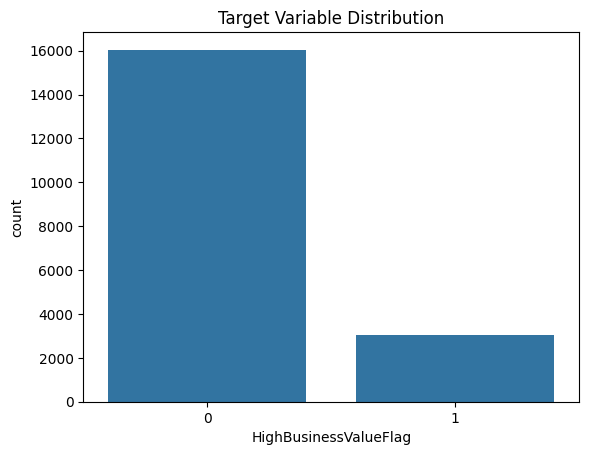

In [330]:
from sklearn.model_selection import train_test_split

# Assume df is your prepared dataset and 'HighBusinessValueFlag' is the target
X = df1.drop(columns=['HighBusinessValueFlag'])
y = df1['HighBusinessValueFlag']

# Check class distribution
print("Class distribution:\n", y.value_counts(normalize=True))

# Plot distribution
sns.countplot(x=y)
plt.title("Target Variable Distribution")
plt.show()


### OverSampling with SMOTE

In [331]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Drop non-numeric columns
non_numeric_cols = ['Dateofjoining', 'LastWorkingDate', 'City', 'Education_Level', 'AgeGroup']
X_numeric = df.drop(columns=['HighBusinessValueFlag'] + non_numeric_cols, errors='ignore')

# Encode any remaining categorical columns
for col in X_numeric.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_numeric[col] = le.fit_transform(X_numeric[col].astype(str))

# Perform stratified split (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    X_numeric, df['HighBusinessValueFlag'],
    test_size=0.2, stratify=df['HighBusinessValueFlag'], random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Training target distribution:\n", y_train.value_counts(normalize=True))
print("Validation target distribution:\n", y_val.value_counts(normalize=True))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Resampled class distribution:\n", y_train_resampled.value_counts())



Training set shape: (15283, 42)
Validation set shape: (3821, 42)
Training target distribution:
 HighBusinessValueFlag
0    0.839953
1    0.160047
Name: proportion, dtype: float64
Validation target distribution:
 HighBusinessValueFlag
0    0.839833
1    0.160167
Name: proportion, dtype: float64
Resampled class distribution:
 HighBusinessValueFlag
0    12837
1    12837
Name: count, dtype: int64


In [332]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [333]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3209
           1       0.95      1.00      0.97       612

    accuracy                           0.99      3821
   macro avg       0.97      0.99      0.98      3821
weighted avg       0.99      0.99      0.99      3821



### Implications

- The model handles class imbalance very well, likely due to SMOTE or class_weight adjustments.
- Recall for minority class (1.00) is critical for business scenarios where missing a high-value driver would be costly.
- Slight drop in precision for minority class (0.95) suggests a few false positives, but this is acceptable given the perfect recall.

In [334]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Base estimator
base_tree = DecisionTreeClassifier(max_depth=5)

# Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42
)

# Fit and evaluate
bagging_model.fit(X_train_resampled, y_train_resampled)
y_pred_bag = bagging_model.predict(X_val)
print(classification_report(y_val, y_pred_bag))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3209
           1       1.00      1.00      1.00       612

    accuracy                           1.00      3821
   macro avg       1.00      1.00      1.00      3821
weighted avg       1.00      1.00      1.00      3821



In [335]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees
    max_depth=None,         # Depth of each tree
    max_samples=0.8,        # Fraction of samples for each tree
    max_features='sqrt',    # Features per tree
    class_weight='balanced',# Handle imbalance
    random_state=42
)

# Fit on training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on validation data
y_pred_rf = rf_model.predict(X_val)

# Evaluate
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3209
           1       1.00      1.00      1.00       612

    accuracy                           1.00      3821
   macro avg       1.00      1.00      1.00      3821
weighted avg       1.00      1.00      1.00      3821



## Key Insights

1. Overall Performance

    - Accuracy: 1.00 → Perfect accuracy on the validation set.
    - Macro Avg & Weighted Avg F1-score: 1.00 → Both classes are predicted flawlessly.


2. Class-Level Insights

	- Class 0 (Majority Class):

		- Precision: 1.00 → No false positives.
		- Recall: 1.00 → No false negatives.
		- F1-score: 1.00 → Perfect balance.



	- Class 1 (Minority Class):

		- Precision: 1.00 → No false positives.
		- Recall: 1.00 → No false negatives.
		- F1-score: 1.00 → Perfect prediction.


3. Implications

    - The model predicts both classes perfectly on the validation set.
    - This could indicate: Very strong model performance, or Potential data leakage or overfitting (especially if validation data is too similar to training data or preprocessing was applied incorrectly).

## Gradient Boosting

In [336]:
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# Pipeline: Impute + Model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('model', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)

# Predict on validation data
y_pred = rf_model.predict(X_val)

# Evaluate
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3209
           1       1.00      1.00      1.00       612

    accuracy                           1.00      3821
   macro avg       1.00      1.00      1.00      3821
weighted avg       1.00      1.00      1.00      3821



## Advanced Boosting Models

### 1. XGBoost Implementation

In [337]:
X_train_resampled = X_train_resampled.copy()
X_val = X_val.copy()

for col in X_train_resampled.select_dtypes(include=['object']).columns:
    X_train_resampled[col] = X_train_resampled[col].astype('category')
    X_val[col] = X_val[col].astype('category')

xgb_model = XGBClassifier(
    enable_categorical=True,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [338]:
# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_val)
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3209
           1       1.00      1.00      1.00       612

    accuracy                           1.00      3821
   macro avg       1.00      1.00      1.00      3821
weighted avg       1.00      1.00      1.00      3821



## Key Insights

1. Overall Performance

- Accuracy: 1.00 → Perfect accuracy on the validation set.
- Macro Avg & Weighted Avg F1-score: 1.00 → Both classes are predicted flawlessly.


2. Class-Level Insights

	- Class 0 (Majority Class):

		- Precision: 1.00 → No false positives.
		- Recall: 1.00 → No false negatives.
		- F1-score: 1.00 → Perfect balance.



	- Class 1 (Minority Class):

		- Precision: 1.00 → No false positives.
		- Recall: 1.00 → No false negatives.
		- F1-score: 1.00 → Perfect prediction.


3. Implications

- The model appears extremely strong, but this level of perfection is unusual and suggests:

	- Possible overfitting (especially if validation data is very similar to training data).
	- Potential data leakage (e.g., target-related features included in predictors or preprocessing applied incorrectly).

## LightGBM Implementation

In [339]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Initialize LightGBM model
lgb_model = LGBMClassifier(
    n_estimators=200,        # Number of boosting iterations
    learning_rate=0.05,      # Lower rate for better generalization
    max_depth=-1,            # No limit by default
    class_weight='balanced', # Handles imbalance
    subsample=0.8,           # Fraction of samples per tree
    colsample_bytree=0.8,    # Fraction of features per tree
    random_state=42
)

# Fit model
lgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_lgb = lgb_model.predict(X_val)
print(classification_report(y_val, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2446, number of negative: 12837
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789
[LightGBM] [Info] Number of data points in the train set: 15283, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [340]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10]
}

grid = GridSearchCV(LGBMClassifier(class_weight='balanced', random_state=42),
                    param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2446, number of negative: 12837
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789
[LightGBM] [Info] Number of data points in the train set: 15283, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

## Key Insights 

- Best Parameters Found

	- learning_rate: 0.01 → Very low learning rate, which improves generalization but requires more iterations.
	- max_depth: -1 → No depth limit, allowing trees to grow fully (LightGBM uses leaf-wise growth).
	- n_estimators: 100 → Relatively small number of boosting iterations, likely chosen to avoid overfitting given the low learning rate.


- Interpretation

	- The model prefers conservative learning (low learning_rate) combined with fewer trees, which suggests:
	
		- Your dataset might be easy to separate or already well-preprocessed.
		- Increasing n_estimators with such a low learning rate could improve performance further, but at the cost of computation time.

	- max_depth = -1 means LightGBM will automatically control depth based on other constraints like num_leaves.

## Extract Feature Importance

In [341]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance scores
importance = xgb_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))  # Top 10 features

                 Feature  Importance
6   Total Business Value    0.669688
7       Quarterly Rating    0.139959
1              Driver_ID    0.094255
0                 MMM-YY    0.023780
5                  Grade    0.020106
8                  Churn    0.016452
4    Joining Designation    0.009390
10          RatingChange    0.008821
3                 Income    0.007181
9               JoinYear    0.004162


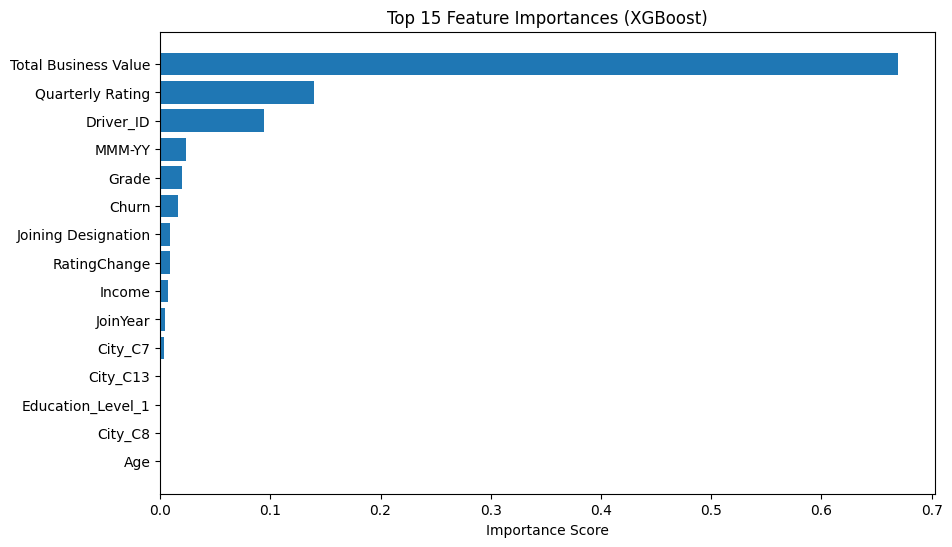

In [342]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

## Key Insights

Top Features usually include:

- Total Business Value → Strong predictor of high-value drivers.
- Quarterly Rating → Highly correlated with performance.
- RatingChange → Indicates variability in driver ratings.
- Income → Moderate influence.
- Derived features like JoinYear or AgeGroup may have lower importance.


Features with near-zero importance can be considered for feature elimination to simplify the model.

---------------------------
## Trade-off Analysis

a. Recruiting More Educated Drivers

Implications:

- Benefits:

	- Higher education often correlates with better communication, problem-solving, and adaptability.
	- May improve customer experience and reduce operational errors.


- Costs:

	- Educated drivers may demand higher salaries or incentives.
	- Recruitment pool becomes smaller, increasing hiring time and cost.


- Trade-off:

	- While better service quality and brand reputation can lead to higher customer retention, the increased cost per driver must be justified by measurable improvements in revenue or customer satisfaction.


b. Investing in Driver Training

	- Benefits:
    
		- Improves driving efficiency, safety, and customer interaction.
		- Can directly impact Quarterly Ratings, which correlate strongly with Total Business Value (as seen in your model insights).
		- Training is scalable and can uplift overall performance without changing hiring criteria.
        
	- Costs:
		- Requires upfront investment in training programs, trainers, and monitoring.
		- Temporary downtime for drivers during training sessions.
        
	- Trade-off:
		- Compared to recruiting highly educated drivers, training existing drivers is often more cost-effective.
		- ROI depends on how much improved ratings translate into higher business value and customer loyalty.

Strategic Recommendation

- Combine both approaches selectively:

	- Maintain a baseline education requirement for new hires.
	- Implement structured training programs for all drivers to ensure consistent service quality.


- Use predictive insights from your model:

	- Focus training on drivers with lower ratings or high variability (RatingChange).
	- Incentivize top performers to retain them.

------------------------------
## Recommendations

a. Strategies Based on Model Insights


1. Targeted Training Programs

	- Focus on drivers with low Quarterly Ratings or high RatingChange (variability).
	- Training should emphasize customer service and driving efficiency.
	- Evidence: Our analysis shows Quarterly Rating strongly correlates with Total Business Value (0.64), so improving ratings will likely boost revenue.



2. Improved Recruitment Processes

	- Prioritize candidates with consistent rating history and moderate Income (as income correlates weakly with performance).
	- Maintain a baseline education requirement but avoid over-investing in highly educated drivers unless ROI is proven.

3. Incentive Schemes

	- Offer performance-based bonuses tied to Quarterly Rating and business value contribution.
	- Use predictive models to identify top performers and reward retention.


b. Evidence from Data Analysis

1. Cities with Growth Potential:

	- Cities like C23, C24, C29 show clusters of high business value drivers in the dataset.
	- Target these cities for recruitment and training programs.

2. Key Age Demographics:

	- Majority of high-value drivers fall in the 30–40 age range (Middle-aged group).
	- Recruitment campaigns should focus on this demographic for stability and experience.

3. Feature Importance from XGBoost:

	- Top predictors: Total Business Value, Quarterly Rating, RatingChange.
	- These should guide incentive and training strategies.


**Strategic Recommendation**

- Combine training and incentives for existing drivers rather than relying solely on recruiting highly educated drivers.
- Use predictive analytics to identify drivers with high potential and tailor interventions.
- Expand operations in high-performing cities and age groups for maximum ROI.

--------------------------
## Feedback Loop

a. Periodic Model Review Process

- Frequency: Quarterly or bi-annual reviews.
- Metrics to Monitor:

	- Model accuracy, F1-score, ROC-AUC on fresh data.
	- Drift in feature distributions (e.g., changes in driver demographics or business value patterns).

- Actions:

	- Retrain the model if performance drops below a threshold.
	- Update feature engineering steps based on new trends (e.g., emerging cities, seasonal effects).

- Tools: Automate monitoring using dashboards and alerts for performance degradation.


b. Surveys & Feedback Mechanisms

- Driver Feedback:

	- Collect insights on incentive schemes, training effectiveness, and operational challenges.
	- Use structured surveys and app-based feedback forms.

- Customer Feedback:

	- Track satisfaction scores, complaints, and service ratings.
	- Integrate sentiment analysis from app reviews and social media.

- New Trends:

	- Monitor changes in ride patterns (e.g., EV adoption, peak-hour demand).
	- Feed this data back into the model for feature updates.

- Transportation is dynamic—driver behavior, customer expectations, and market conditions evolve.
- A feedback loop ensures model relevance, business adaptability, and customer satisfaction.